In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Data loaded successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded successfully
X_train shape: (20232, 9)
X_test shape: (5059, 9)


In [2]:
# Always predict mean valence
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

# Results table
results = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Linear Regression', 'Ridge Regression'],
    'MSE': [baseline_mse, lr_mse, ridge_mse],
    'R2': [baseline_r2, lr_r2, ridge_r2]
})

print("=== MODEL RESULTS ===")
print(results.round(4))

=== MODEL RESULTS ===
               Model     MSE      R2
0    Baseline (mean)  0.0198 -0.0000
1  Linear Regression  0.0182  0.0809
2   Ridge Regression  0.0182  0.0809


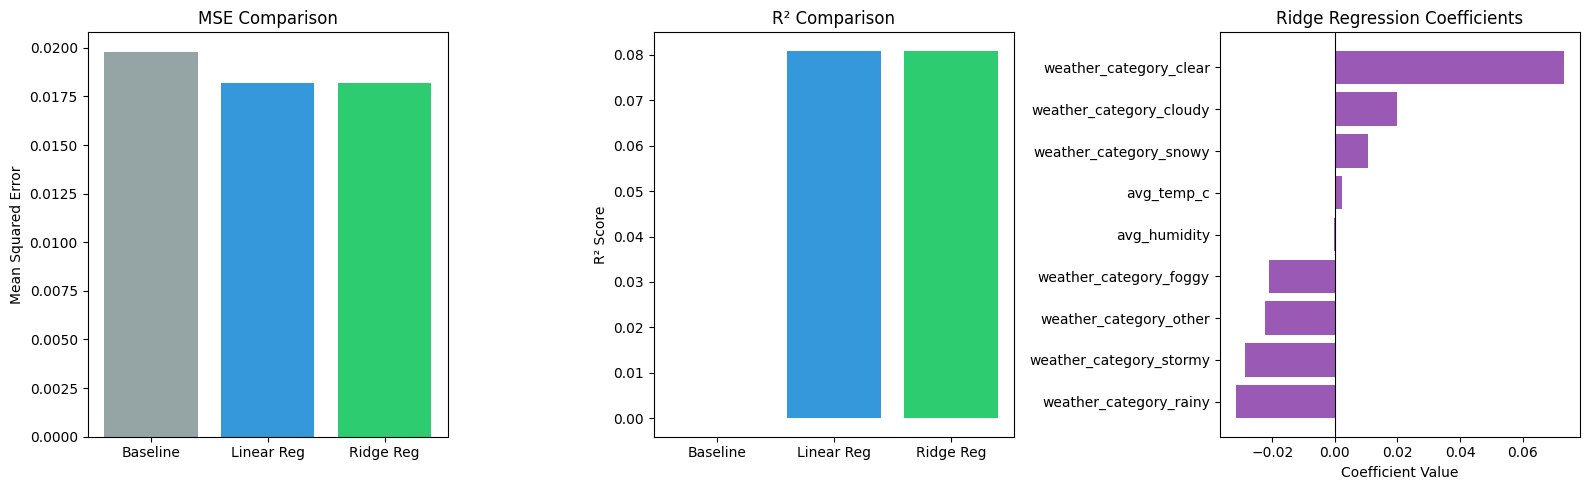


Ridge Coefficients:
                feature  coefficient
 weather_category_rainy      -0.0316
weather_category_stormy      -0.0286
 weather_category_other      -0.0222
 weather_category_foggy      -0.0210
           avg_humidity      -0.0003
             avg_temp_c       0.0023
 weather_category_snowy       0.0105
weather_category_cloudy       0.0199
 weather_category_clear       0.0731


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Model comparison bar chart
models = ['Baseline', 'Linear Reg', 'Ridge Reg']
mse_vals = [baseline_mse, lr_mse, ridge_mse]
r2_vals = [baseline_r2, lr_r2, ridge_r2]

axes[0].bar(models, mse_vals, color=['#95a5a6', '#3498db', '#2ecc71'])
axes[0].set_title('MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')

# Plot 2: R2 comparison
axes[1].bar(models, r2_vals, color=['#95a5a6', '#3498db', '#2ecc71'])
axes[1].set_title('R² Comparison')
axes[1].set_ylabel('R² Score')

# Plot 3: Feature coefficients from Ridge
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge.coef_
}).sort_values('coefficient')

axes[2].barh(coef_df['feature'], coef_df['coefficient'], color='#9b59b6')
axes[2].set_title('Ridge Regression Coefficients')
axes[2].set_xlabel('Coefficient Value')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../results/figures/regression_results.png', dpi=150)
plt.show()

print("\nRidge Coefficients:")
print(coef_df.round(4).to_string(index=False))